In [1]:
import os
os.listdir('/kaggle/input/competitions/home-credit-default-risk/')

['sample_submission.csv',
 'bureau_balance.csv',
 'POS_CASH_balance.csv',
 'application_train.csv',
 'HomeCredit_columns_description.csv',
 'application_test.csv',
 'previous_application.csv',
 'credit_card_balance.csv',
 'installments_payments.csv',
 'bureau.csv']

In [2]:
# ============================================
# PROJET 2 - CREDIT RISK - LYNDA
# Phase 1 : EDA - Exploration & Nettoyage
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Chemin dataset
PATH = '/kaggle/input/competitions/home-credit-default-risk/'

# Chargement table principale
df = pd.read_csv(PATH + 'application_train.csv')

print(f"✓ Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

✓ Dataset chargé : 307,511 lignes × 122 colonnes


=== STRUCTURE ===
Lignes    : 307,511
Colonnes  : 122
Mémoire   : 286.2 MB

=== TARGET (variable cible) ===
0 - Remboursement normal : 282,686 (91.9%)
1 - Défaut de paiement   : 24,825 (8.1%)


/tmp/ipykernel_57/3682082184.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TARGET', data=df, palette=['#378ADD', '#E24B4A'])


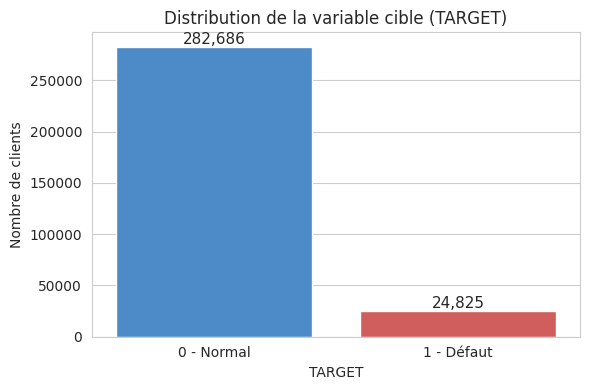


=== VALEURS MANQUANTES (top 20 colonnes) ===
Colonnes avec NaN : 67 / 122
                          Manquants  Pourcentage
COMMONAREA_MEDI              214865       69.900
COMMONAREA_MODE              214865       69.900
COMMONAREA_AVG               214865       69.900
NONLIVINGAPARTMENTS_MODE     213514       69.400
NONLIVINGAPARTMENTS_MEDI     213514       69.400
NONLIVINGAPARTMENTS_AVG      213514       69.400
LIVINGAPARTMENTS_AVG         210199       68.400
LIVINGAPARTMENTS_MEDI        210199       68.400
FONDKAPREMONT_MODE           210295       68.400
LIVINGAPARTMENTS_MODE        210199       68.400
FLOORSMIN_MEDI               208642       67.800
FLOORSMIN_MODE               208642       67.800
FLOORSMIN_AVG                208642       67.800
YEARS_BUILD_MODE             204488       66.500
YEARS_BUILD_MEDI             204488       66.500
YEARS_BUILD_AVG              204488       66.500
OWN_CAR_AGE                  202929       66.000
LANDAREA_AVG                 182590       5

In [3]:
# ============================================
# Q1 - Structure générale
# ============================================
print("=== STRUCTURE ===")
print(f"Lignes    : {df.shape[0]:,}")
print(f"Colonnes  : {df.shape[1]}")
print(f"Mémoire   : {df.memory_usage().sum() / 1024**2:.1f} MB")

# ============================================
# Q2 - Variable cible
# ============================================
print("\n=== TARGET (variable cible) ===")
target_counts = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True) * 100
print(f"0 - Remboursement normal : {target_counts[0]:,} ({target_pct[0]:.1f}%)")
print(f"1 - Défaut de paiement   : {target_counts[1]:,} ({target_pct[1]:.1f}%)")

# ============================================
# Q3 - Déséquilibre de classes
# ============================================
plt.figure(figsize=(6, 4))
sns.countplot(x='TARGET', data=df, palette=['#378ADD', '#E24B4A'])
plt.title('Distribution de la variable cible (TARGET)')
plt.xticks([0, 1], ['0 - Normal', '1 - Défaut'])
plt.ylabel('Nombre de clients')
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():,.0f}', 
                       (p.get_x() + p.get_width()/2, p.get_height()),
                       ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

# ============================================
# Q4 - Valeurs manquantes
# ============================================
print("\n=== VALEURS MANQUANTES (top 20 colonnes) ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Manquants': missing, 'Pourcentage': missing_pct})
missing_df = missing_df[missing_df['Manquants'] > 0].sort_values('Pourcentage', ascending=False)
print(f"Colonnes avec NaN : {len(missing_df)} / {df.shape[1]}")
print(missing_df.head(20).to_string())

# ============================================
# Q5 - Types de variables
# ============================================
print("\n=== TYPES DE VARIABLES ===")
print(f"Numériques  : {df.select_dtypes(include=['int64','float64']).shape[1]}")
print(f"Catégorielles : {df.select_dtypes(include=['object']).shape[1]}")

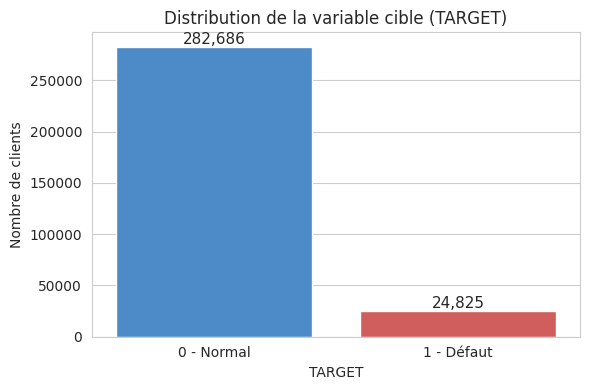

🔴 Colonnes > 40% NaN (à supprimer ou traiter) : 49
🟡 Colonnes 10-40% NaN (imputation médiane/mode) : 8
🟢 Colonnes < 10% NaN (imputation simple) : 10


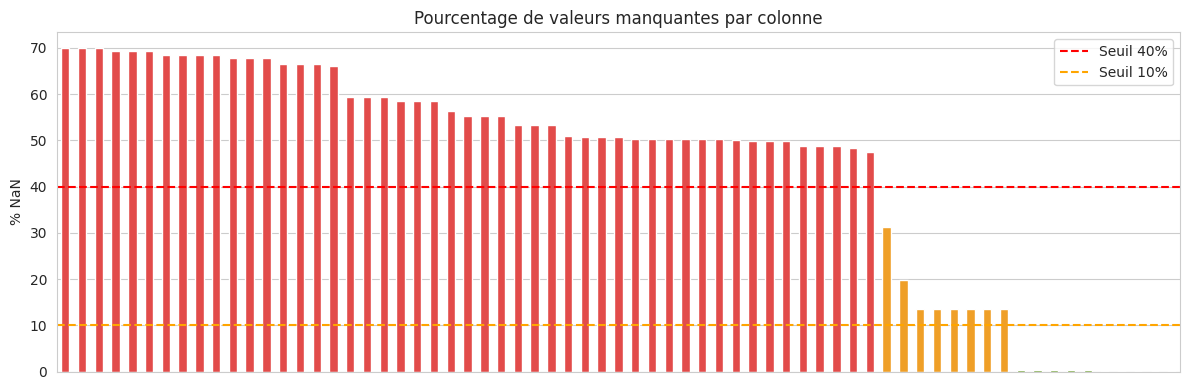

In [4]:
# ============================================
# CORRECTION WARNING + VISUALISATION TARGET
# ============================================
plt.figure(figsize=(6, 4))
sns.countplot(x='TARGET', data=df, hue='TARGET', 
              palette={0: '#378ADD', 1: '#E24B4A'}, legend=False)
plt.title('Distribution de la variable cible (TARGET)')
plt.xticks([0, 1], ['0 - Normal', '1 - Défaut'])
plt.ylabel('Nombre de clients')
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():,.0f}',
                       (p.get_x() + p.get_width()/2, p.get_height()),
                       ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

# ============================================
# ANALYSE VALEURS MANQUANTES — SEUILS
# ============================================
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

seuil_haut = missing_pct[missing_pct > 40]
seuil_moyen = missing_pct[(missing_pct > 10) & (missing_pct <= 40)]
seuil_bas = missing_pct[(missing_pct > 0) & (missing_pct <= 10)]

print(f"🔴 Colonnes > 40% NaN (à supprimer ou traiter) : {len(seuil_haut)}")
print(f"🟡 Colonnes 10-40% NaN (imputation médiane/mode) : {len(seuil_moyen)}")
print(f"🟢 Colonnes < 10% NaN (imputation simple) : {len(seuil_bas)}")

# Visualisation
plt.figure(figsize=(12, 4))
missing_pct[missing_pct > 0].plot(kind='bar', 
                                   color=['#E24B4A' if x > 40 
                                          else '#EF9F27' if x > 10 
                                          else '#639922' 
                                          for x in missing_pct[missing_pct > 0]])
plt.axhline(y=40, color='red', linestyle='--', label='Seuil 40%')
plt.axhline(y=10, color='orange', linestyle='--', label='Seuil 10%')
plt.title('Pourcentage de valeurs manquantes par colonne')
plt.ylabel('% NaN')
plt.xlabel('')
plt.xticks([])
plt.legend()
plt.tight_layout()
plt.show()

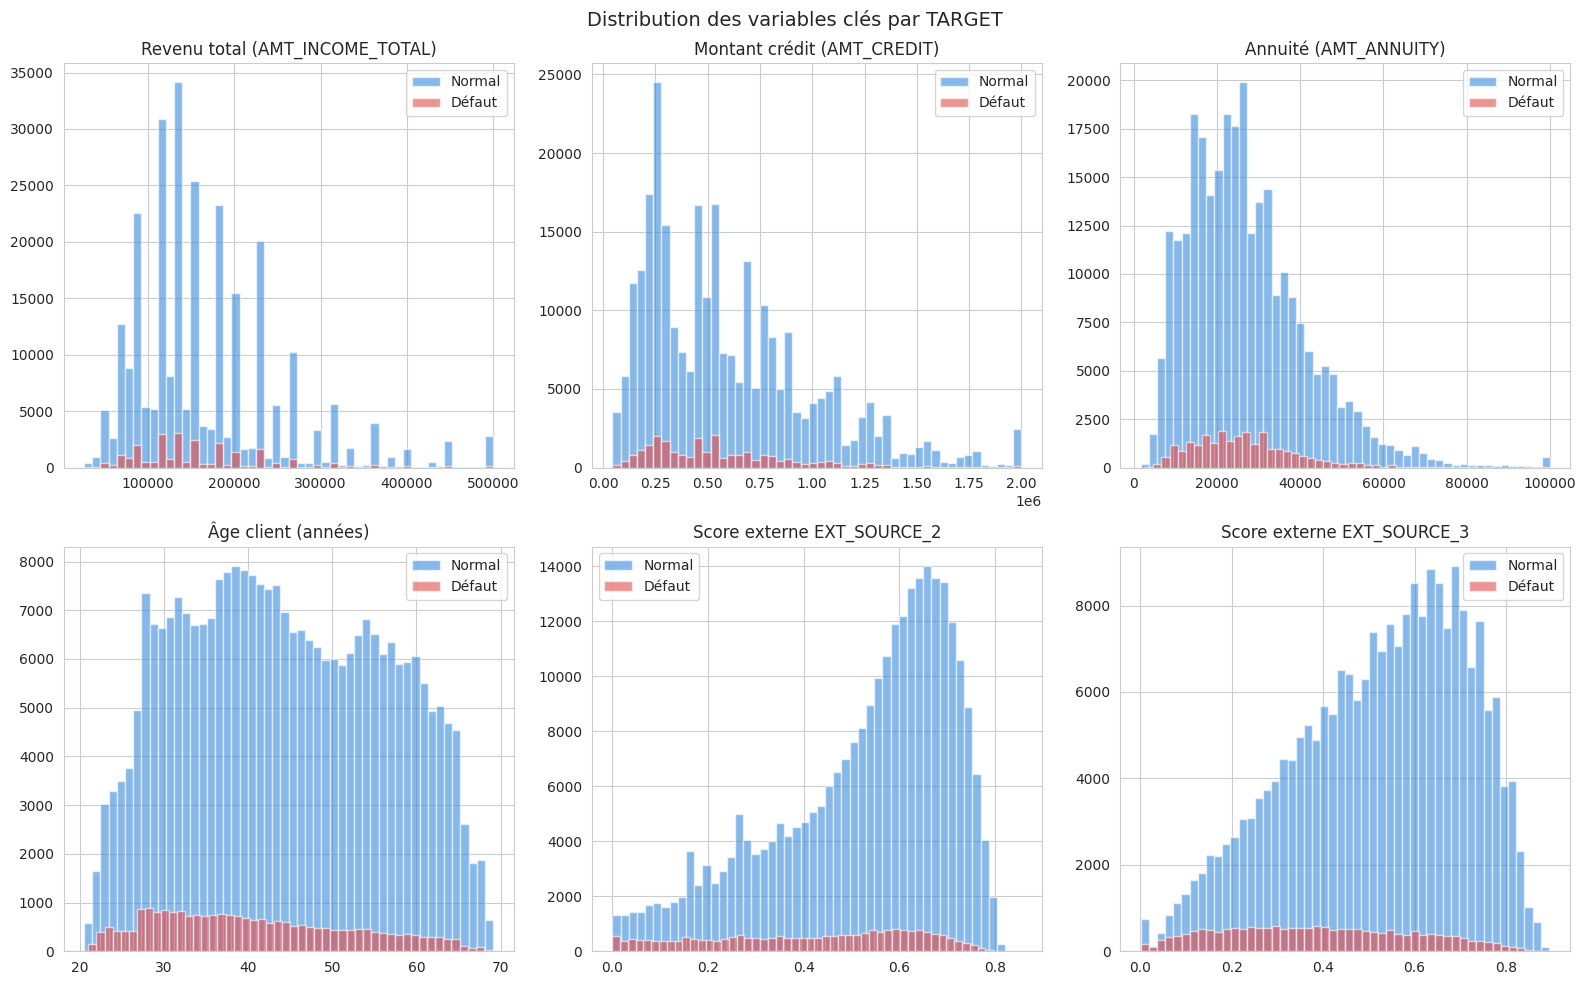

=== CORRÉLATION AVEC TARGET ===
EXT_SOURCE_3   -0.179
EXT_SOURCE_2   -0.160
EXT_SOURCE_1   -0.155
TARGET          1.000
Name: TARGET, dtype: float64

=== MOYENNES EXT_SOURCE PAR TARGET ===
        EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3
TARGET                                          
0              0.511         0.523         0.521
1              0.387         0.411         0.391


In [5]:
# ============================================
# EXPLORATION VARIABLES CLÉS
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution des variables clés par TARGET', fontsize=14)

# 1. Revenu total
ax1 = axes[0, 0]
df[df['TARGET']==0]['AMT_INCOME_TOTAL'].clip(upper=500000).hist(
    bins=50, ax=ax1, alpha=0.6, color='#378ADD', label='Normal')
df[df['TARGET']==1]['AMT_INCOME_TOTAL'].clip(upper=500000).hist(
    bins=50, ax=ax1, alpha=0.6, color='#E24B4A', label='Défaut')
ax1.set_title('Revenu total (AMT_INCOME_TOTAL)')
ax1.legend()

# 2. Montant du crédit
ax2 = axes[0, 1]
df[df['TARGET']==0]['AMT_CREDIT'].clip(upper=2000000).hist(
    bins=50, ax=ax2, alpha=0.6, color='#378ADD', label='Normal')
df[df['TARGET']==1]['AMT_CREDIT'].clip(upper=2000000).hist(
    bins=50, ax=ax2, alpha=0.6, color='#E24B4A', label='Défaut')
ax2.set_title('Montant crédit (AMT_CREDIT)')
ax2.legend()

# 3. Annuité
ax3 = axes[0, 2]
df[df['TARGET']==0]['AMT_ANNUITY'].clip(upper=100000).hist(
    bins=50, ax=ax3, alpha=0.6, color='#378ADD', label='Normal')
df[df['TARGET']==1]['AMT_ANNUITY'].clip(upper=100000).hist(
    bins=50, ax=ax3, alpha=0.6, color='#E24B4A', label='Défaut')
ax3.set_title('Annuité (AMT_ANNUITY)')
ax3.legend()

# 4. Age (DAYS_BIRTH → années)
ax4 = axes[1, 0]
(-df[df['TARGET']==0]['DAYS_BIRTH'] / 365).hist(
    bins=50, ax=ax4, alpha=0.6, color='#378ADD', label='Normal')
(-df[df['TARGET']==1]['DAYS_BIRTH'] / 365).hist(
    bins=50, ax=ax4, alpha=0.6, color='#E24B4A', label='Défaut')
ax4.set_title('Âge client (années)')
ax4.legend()

# 5. EXT_SOURCE_2 (score externe)
ax5 = axes[1, 1]
df[df['TARGET']==0]['EXT_SOURCE_2'].hist(
    bins=50, ax=ax5, alpha=0.6, color='#378ADD', label='Normal')
df[df['TARGET']==1]['EXT_SOURCE_2'].hist(
    bins=50, ax=ax5, alpha=0.6, color='#E24B4A', label='Défaut')
ax5.set_title('Score externe EXT_SOURCE_2')
ax5.legend()

# 6. EXT_SOURCE_3
ax6 = axes[1, 2]
df[df['TARGET']==0]['EXT_SOURCE_3'].dropna().hist(
    bins=50, ax=ax6, alpha=0.6, color='#378ADD', label='Normal')
df[df['TARGET']==1]['EXT_SOURCE_3'].dropna().hist(
    bins=50, ax=ax6, alpha=0.6, color='#E24B4A', label='Défaut')
ax6.set_title('Score externe EXT_SOURCE_3')
ax6.legend()

plt.tight_layout()
plt.show()

# ============================================
# ANALYSE EXT_SOURCE — les variables les plus
# prédictives selon la littérature
# ============================================
print("=== CORRÉLATION AVEC TARGET ===")
ext_corr = df[['EXT_SOURCE_1','EXT_SOURCE_2',
               'EXT_SOURCE_3','TARGET']].corr()['TARGET'].sort_values()
print(ext_corr)

print("\n=== MOYENNES EXT_SOURCE PAR TARGET ===")
print(df.groupby('TARGET')[['EXT_SOURCE_1',
                             'EXT_SOURCE_2',
                             'EXT_SOURCE_3']].mean().round(3))

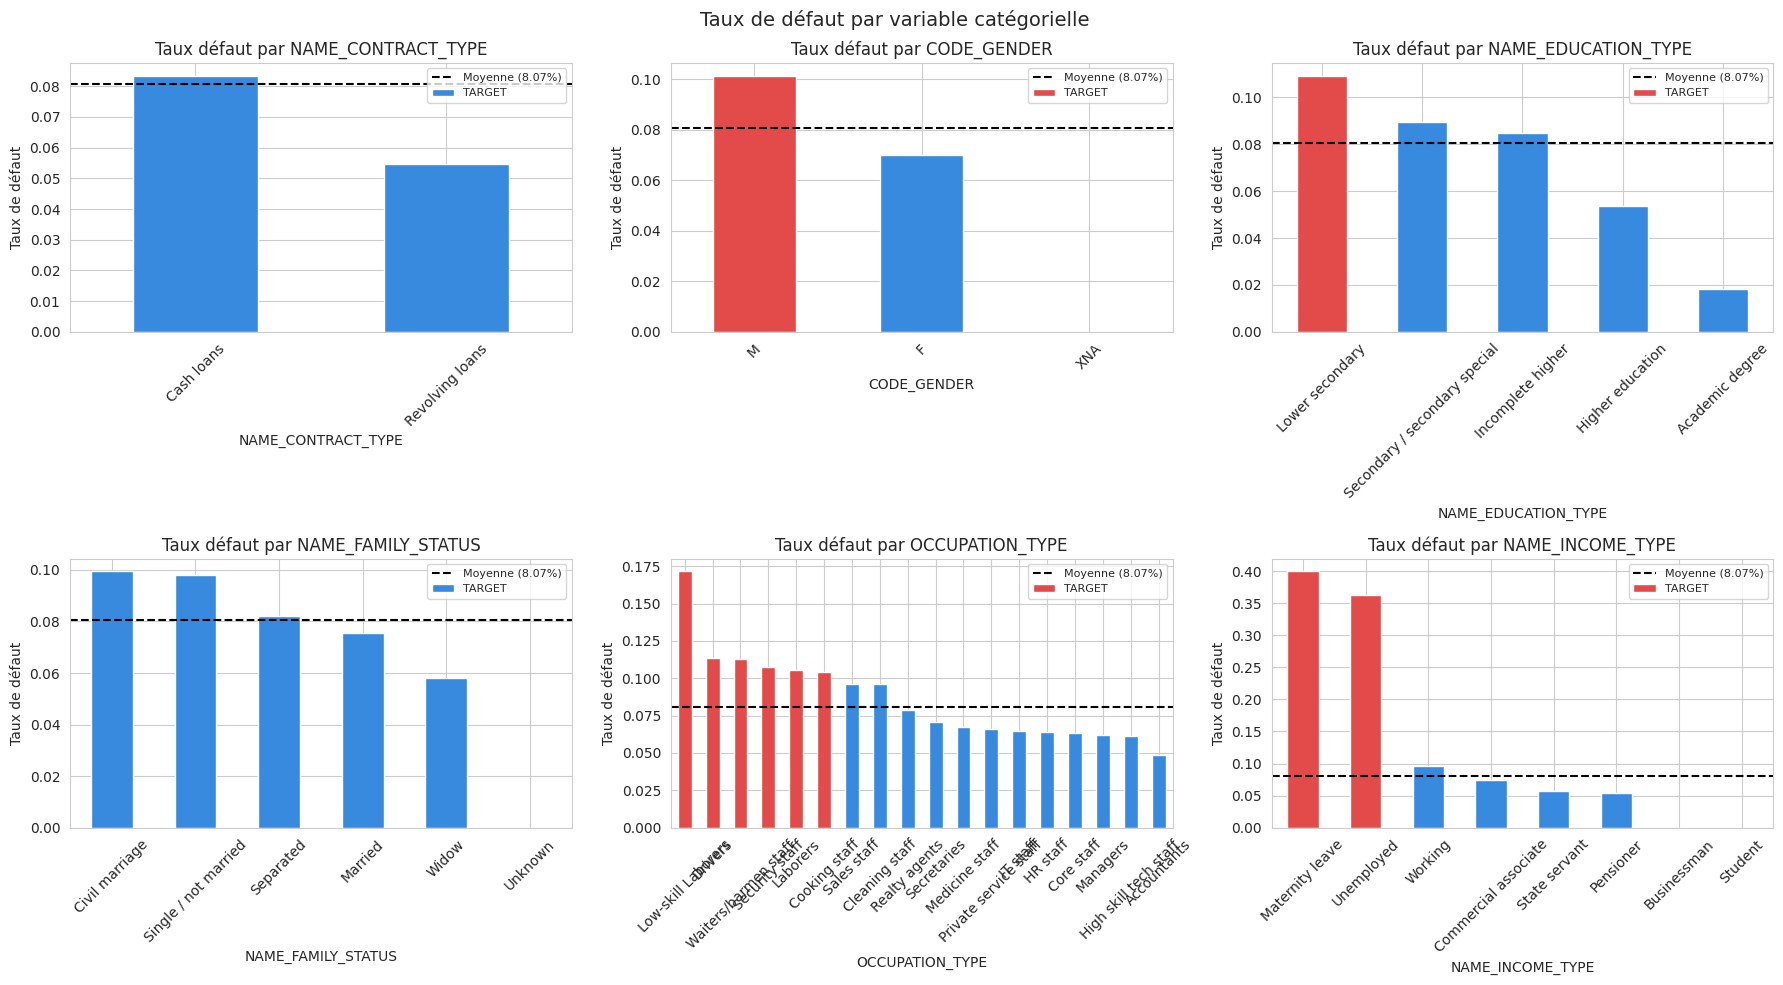

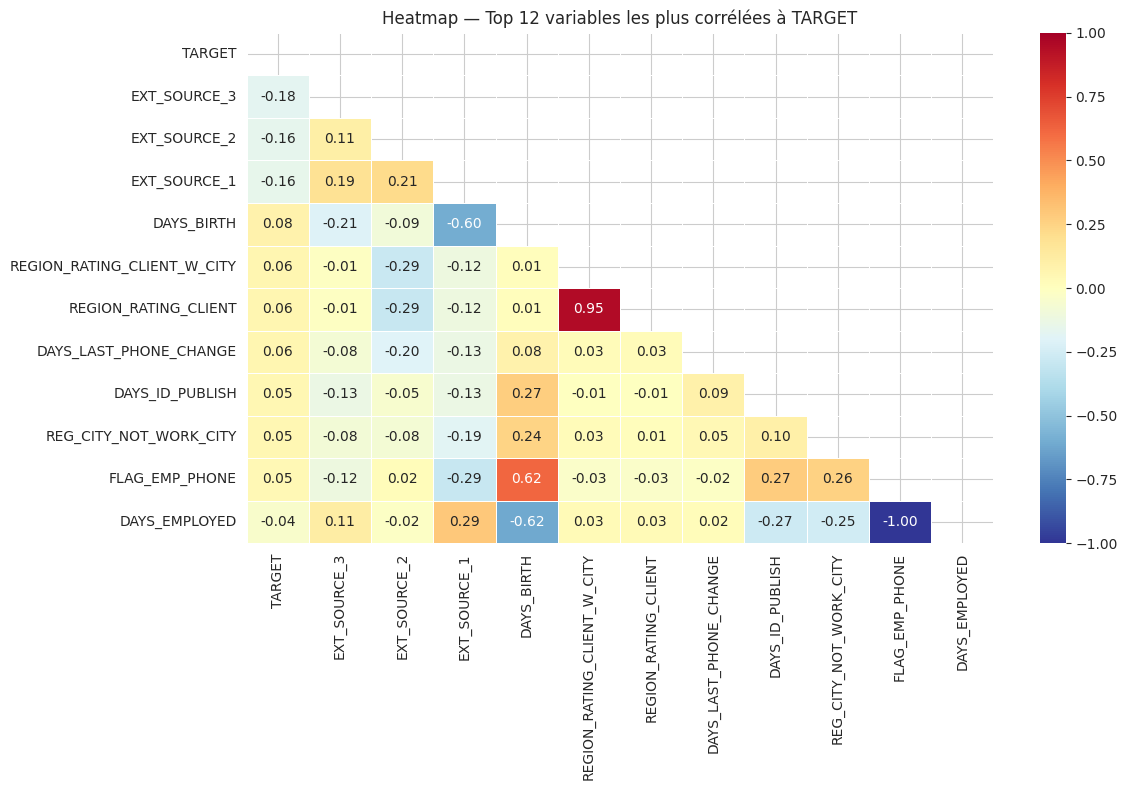

=== ANOMALIE DAYS_EMPLOYED ===
Valeur max DAYS_EMPLOYED : 365,243
Clients avec valeur 365243 : 55,374
Taux défaut clients normaux : 8.66%
Taux défaut clients anomalie : 5.40%


In [6]:
# ============================================
# VARIABLES CATÉGORIELLES vs TARGET
# ============================================

cat_cols = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 
            'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
            'OCCUPATION_TYPE', 'NAME_INCOME_TYPE']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Taux de défaut par variable catégorielle', fontsize=14)

for idx, col in enumerate(cat_cols):
    ax = axes[idx//3, idx%3]
    default_rate = df.groupby(col)['TARGET'].mean().sort_values(ascending=False)
    default_rate.plot(kind='bar', ax=ax, 
                      color=['#E24B4A' if x > 0.1 else '#378ADD' 
                             for x in default_rate])
    ax.set_title(f'Taux défaut par {col}')
    ax.set_ylabel('Taux de défaut')
    ax.axhline(y=df['TARGET'].mean(), color='black', 
               linestyle='--', label=f'Moyenne ({df["TARGET"].mean():.2%})')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ============================================
# HEATMAP CORRÉLATIONS — top variables numériques
# ============================================
top_corr_cols = df.corr(numeric_only=True)['TARGET']\
                  .abs()\
                  .sort_values(ascending=False)\
                  .head(12).index.tolist()

plt.figure(figsize=(12, 8))
corr_matrix = df[top_corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Heatmap — Top 12 variables les plus corrélées à TARGET')
plt.tight_layout()
plt.show()

# ============================================
# ANOMALIE DAYS_EMPLOYED — bug connu du dataset
# ============================================
print("=== ANOMALIE DAYS_EMPLOYED ===")
print(f"Valeur max DAYS_EMPLOYED : {df['DAYS_EMPLOYED'].max():,}")
print(f"Clients avec valeur 365243 : {(df['DAYS_EMPLOYED'] == 365243).sum():,}")
print(f"Taux défaut clients normaux : {df[df['DAYS_EMPLOYED'] != 365243]['TARGET'].mean():.2%}")
print(f"Taux défaut clients anomalie : {df[df['DAYS_EMPLOYED'] == 365243]['TARGET'].mean():.2%}")

In [7]:
# ============================================
# NETTOYAGE FINAL — Phase 1
# ============================================

df_clean = df.copy()

# 1. Corriger anomalie DAYS_EMPLOYED
df_clean['DAYS_EMPLOYED'] = df_clean['DAYS_EMPLOYED'].replace(365243, np.nan)
print(f"✓ Anomalie DAYS_EMPLOYED corrigée")

# 2. Créer flag pour indiquer l'anomalie (info utile pour le modèle)
df_clean['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
print(f"✓ Flag DAYS_EMPLOYED_ANOM créé")

# 3. Convertir DAYS_BIRTH en âge positif (années)
df_clean['AGE_YEARS'] = (-df_clean['DAYS_BIRTH'] / 365).round(1)
print(f"✓ AGE_YEARS créé : min={df_clean['AGE_YEARS'].min():.0f} ans, "
      f"max={df_clean['AGE_YEARS'].max():.0f} ans")

# 4. Supprimer colonnes > 40% NaN
cols_to_drop = df_clean.columns[
    df_clean.isnull().mean() > 0.40
].tolist()
df_clean = df_clean.drop(columns=cols_to_drop)
print(f"✓ {len(cols_to_drop)} colonnes > 40% NaN supprimées")
print(f"✓ Dimensions après nettoyage : {df_clean.shape}")

# 5. Imputer colonnes 10-40% NaN
num_cols = df_clean.select_dtypes(include=['float64','int64']).columns
cat_cols = df_clean.select_dtypes(include=['object']).columns

for col in num_cols:
    if df_clean[col].isnull().mean() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols:
    if df_clean[col].isnull().mean() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(f"✓ Imputation terminée")
print(f"✓ NaN restants : {df_clean.isnull().sum().sum()}")

# ============================================
# RÉSUMÉ PHASE 1
# ============================================
print("\n" + "="*50)
print("RÉSUMÉ PHASE 1 — EDA & NETTOYAGE")
print("="*50)
print(f"Dataset original  : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Dataset nettoyé   : {df_clean.shape[0]:,} lignes × {df_clean.shape[1]} colonnes")
print(f"Colonnes supprimées : {df.shape[1] - df_clean.shape[1]}")
print(f"Taux de défaut    : {df_clean['TARGET'].mean():.2%}")
print(f"NaN restants      : {df_clean.isnull().sum().sum()}")
print("\n✅ Phase 1 terminée — Prêt pour le Feature Engineering")

✓ Anomalie DAYS_EMPLOYED corrigée
✓ Flag DAYS_EMPLOYED_ANOM créé
✓ AGE_YEARS créé : min=20 ans, max=69 ans
✓ 49 colonnes > 40% NaN supprimées
✓ Dimensions après nettoyage : (307511, 75)
✓ Imputation terminée
✓ NaN restants : 0

RÉSUMÉ PHASE 1 — EDA & NETTOYAGE
Dataset original  : 307,511 lignes × 122 colonnes
Dataset nettoyé   : 307,511 lignes × 75 colonnes
Colonnes supprimées : 47
Taux de défaut    : 8.07%
NaN restants      : 0

✅ Phase 1 terminée — Prêt pour le Feature Engineering


In [8]:
# ============================================
# PHASE 2 — FEATURE ENGINEERING
# Créer de nouvelles variables métier
# ============================================

df_fe = df_clean.copy()

# ============================================
# BLOC 1 — Ratios financiers clés
# (ce qu'un analyste financier calcule en 1er)
# ============================================

# Ratio dette/revenu — combien le crédit pèse vs revenu annuel
df_fe['CREDIT_INCOME_RATIO'] = df_fe['AMT_CREDIT'] / df_fe['AMT_INCOME_TOTAL']

# Ratio annuité/revenu — charge mensuelle vs revenu
df_fe['ANNUITY_INCOME_RATIO'] = df_fe['AMT_ANNUITY'] / df_fe['AMT_INCOME_TOTAL']

# Ratio crédit/valeur du bien — LTV (Loan-To-Value)
df_fe['CREDIT_GOODS_RATIO'] = df_fe['AMT_CREDIT'] / df_fe['AMT_GOODS_PRICE']

# Revenu par membre de la famille
df_fe['INCOME_PER_PERSON'] = df_fe['AMT_INCOME_TOTAL'] / df_fe['CNT_FAM_MEMBERS']

# Durée estimée du prêt en années
df_fe['LOAN_DURATION_YEARS'] = df_fe['AMT_CREDIT'] / df_fe['AMT_ANNUITY'] / 12

print("✓ Ratios financiers créés")
print(df_fe[['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO',
             'CREDIT_GOODS_RATIO', 'INCOME_PER_PERSON',
             'LOAN_DURATION_YEARS']].describe().round(3))

✓ Ratios financiers créés
       CREDIT_INCOME_RATIO  ANNUITY_INCOME_RATIO  CREDIT_GOODS_RATIO  \
count           307511.000            307511.000          307511.000   
mean                 3.958                 0.181               1.123   
std                  2.690                 0.095               0.126   
min                  0.005                 0.000               0.150   
25%                  2.019                 0.115               1.000   
50%                  3.265                 0.163               1.119   
75%                  5.160                 0.229               1.198   
max                 84.737                 1.876               6.000   

       INCOME_PER_PERSON  LOAN_DURATION_YEARS  
count         307511.000           307511.000  
mean           93106.335                1.801  
std           101373.314                0.652  
min             2812.500                0.527  
25%            47250.000                1.301  
50%            75000.000             

In [9]:
# ============================================
# BLOC 2 — Variables temporelles & âge
# ============================================

# Ancienneté emploi en années (valeur positive)
df_fe['EMPLOYMENT_YEARS'] = (-df_fe['DAYS_EMPLOYED']).clip(lower=0) / 365

# Ancienneté du dossier client
df_fe['REGISTRATION_YEARS'] = -df_fe['DAYS_REGISTRATION'] / 365

# Ancienneté du document d'identité
df_fe['ID_PUBLISH_YEARS'] = -df_fe['DAYS_ID_PUBLISH'] / 365

# Ratio âge/ancienneté emploi — stabilité professionnelle
df_fe['EMPLOYMENT_AGE_RATIO'] = df_fe['EMPLOYMENT_YEARS'] / df_fe['AGE_YEARS']

print("✓ Variables temporelles créées")


✓ Variables temporelles créées


In [10]:
# ============================================
# BLOC 3  — Score composite EXT_SOURCE
# (seulement 2 et 3 disponibles)
# ============================================

# Moyenne des 2 scores disponibles
df_fe['EXT_SOURCE_MEAN'] = df_fe[['EXT_SOURCE_2',
                                   'EXT_SOURCE_3']].mean(axis=1)

# Score pondéré (EXT_SOURCE_3 légèrement plus corrélé)
df_fe['EXT_SOURCE_WEIGHTED'] = (
    df_fe['EXT_SOURCE_2'] * 0.45 +
    df_fe['EXT_SOURCE_3'] * 0.55
)

# Minimum des scores (pire score = signal de risque)
df_fe['EXT_SOURCE_MIN'] = df_fe[['EXT_SOURCE_2',
                                  'EXT_SOURCE_3']].min(axis=1)

# Différence entre les 2 scores (écart = instabilité)
df_fe['EXT_SOURCE_DIFF'] = abs(df_fe['EXT_SOURCE_2'] - df_fe['EXT_SOURCE_3'])

print("✓ Scores EXT_SOURCE composites créés")

# ============================================
# BLOC 4 — Encodage variables catégorielles
# ============================================
df_fe = pd.get_dummies(df_fe,
                        columns=df_fe.select_dtypes('object').columns.tolist(),
                        drop_first=True)

print(f"✓ Encodage terminé")
print(f"✓ Dimensions finales : {df_fe.shape}")

# ============================================
# CORRÉLATIONS NOUVELLES VARIABLES vs TARGET
# ============================================
new_features = ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO',
                'CREDIT_GOODS_RATIO', 'INCOME_PER_PERSON',
                'LOAN_DURATION_YEARS', 'EMPLOYMENT_YEARS',
                'EXT_SOURCE_MEAN', 'EXT_SOURCE_WEIGHTED',
                'EXT_SOURCE_MIN', 'EXT_SOURCE_DIFF',
                'EMPLOYMENT_AGE_RATIO']

print("\n=== CORRÉLATION NOUVELLES VARIABLES vs TARGET ===")
new_corr = df_fe[new_features + ['TARGET']].corr()['TARGET']\
             .drop('TARGET').sort_values()
print(new_corr.round(3))

✓ Scores EXT_SOURCE composites créés
✓ Encodage terminé
✓ Dimensions finales : (307511, 188)

=== CORRÉLATION NOUVELLES VARIABLES vs TARGET ===
EXT_SOURCE_MEAN        -0.214
EXT_SOURCE_WEIGHTED    -0.213
EXT_SOURCE_MIN         -0.190
EMPLOYMENT_YEARS       -0.063
EMPLOYMENT_AGE_RATIO   -0.050
LOAN_DURATION_YEARS    -0.032
CREDIT_INCOME_RATIO    -0.008
INCOME_PER_PERSON      -0.007
ANNUITY_INCOME_RATIO    0.014
EXT_SOURCE_DIFF         0.063
CREDIT_GOODS_RATIO      0.068
Name: TARGET, dtype: float64


=== RÉSUMÉ PHASE 2 — FEATURE ENGINEERING ===
Features originales nettoyées : 75
Nouvelles features créées     : 11
Features après encodage       : 186
Observations                  : 307,511
Taux de défaut (TARGET=1)     : 8.07%

=== TOP 15 FEATURES LES PLUS PRÉDICTIVES ===
EXT_SOURCE_MEAN                        0.214
EXT_SOURCE_WEIGHTED                    0.213
EXT_SOURCE_MIN                         0.190
EXT_SOURCE_2                           0.160
EXT_SOURCE_3                           0.156
DAYS_BIRTH                             0.078
AGE_YEARS                              0.078
CREDIT_GOODS_RATIO                     0.068
EMPLOYMENT_YEARS                       0.063
DAYS_EMPLOYED                          0.063
EXT_SOURCE_DIFF                        0.063
REGION_RATING_CLIENT_W_CITY            0.061
REGION_RATING_CLIENT                   0.059
NAME_INCOME_TYPE_Working               0.057
NAME_EDUCATION_TYPE_Higher education   0.057
Name: TARGET, dtype: float64


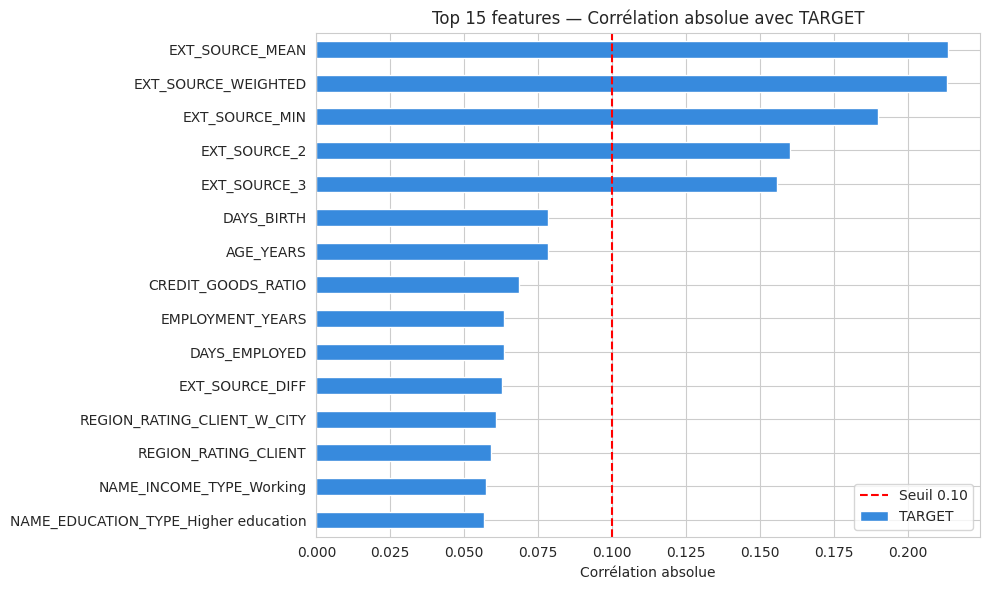


✅ Phase 2 terminée — Prêt pour la modélisation ML


In [11]:
# ============================================
# RÉSUMÉ PHASE 2 + PRÉPARATION MODÈLE
# ============================================

# Séparer features et target
X = df_fe.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df_fe['TARGET']

print("=== RÉSUMÉ PHASE 2 — FEATURE ENGINEERING ===")
print(f"Features originales nettoyées : 75")
print(f"Nouvelles features créées     : 11")
print(f"Features après encodage       : {X.shape[1]}")
print(f"Observations                  : {X.shape[0]:,}")
print(f"Taux de défaut (TARGET=1)     : {y.mean():.2%}")

# Top 15 features par corrélation absolue avec TARGET
print("\n=== TOP 15 FEATURES LES PLUS PRÉDICTIVES ===")
correlations = df_fe.corr(numeric_only=True)['TARGET']\
                    .drop('TARGET')\
                    .abs()\
                    .sort_values(ascending=False)\
                    .head(15)
print(correlations.round(3))

# Visualisation top 15
plt.figure(figsize=(10, 6))
correlations.sort_values().plot(kind='barh', color='#378ADD')
plt.title('Top 15 features — Corrélation absolue avec TARGET')
plt.xlabel('Corrélation absolue')
plt.axvline(x=0.1, color='red', linestyle='--', label='Seuil 0.10')
plt.legend()
plt.tight_layout()
plt.show()

print("\n✅ Phase 2 terminée — Prêt pour la modélisation ML")

In [12]:
# ============================================
# PHASE 3 — MODÉLISATION ML
# ============================================

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Supprimer DAYS_BIRTH (redondant avec AGE_YEARS)
X = X.drop(columns=['DAYS_BIRTH'], errors='ignore')

# ============================================
# SPLIT TRAIN/TEST STRATIFIÉ
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # important pour données déséquilibrées
)

print(f"✓ Train : {X_train.shape[0]:,} observations")
print(f"✓ Test  : {X_test.shape[0]:,} observations")
print(f"✓ Taux défaut train : {y_train.mean():.2%}")
print(f"✓ Taux défaut test  : {y_test.mean():.2%}")



✓ Train : 246,008 observations
✓ Test  : 61,503 observations
✓ Taux défaut train : 8.07%
✓ Taux défaut test  : 8.07%


In [13]:
# SMOTE 
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"✓ Avant SMOTE : {y_train.value_counts().to_dict()}")
print(f"✓ Après SMOTE : {pd.Series(y_train_sm).value_counts().to_dict()}")
print(f"✓ Nouvelles dimensions train : {X_train_sm.shape}")

✓ Avant SMOTE : {0: 226148, 1: 19860}
✓ Après SMOTE : {0: 226148, 1: 226148}
✓ Nouvelles dimensions train : (452296, 185)


In [14]:
# ============================================
# MODÈLE 1 — Régression Logistique
# (baseline obligatoire de tout projet ML pro)
# ============================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

# Normalisation obligatoire pour Régression Logistique
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

print("Entraînement Régression Logistique...")
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train_scaled, y_train_sm)

# Prédictions
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

# Métriques
auc_lr = roc_auc_score(y_test, y_prob_lr)
print(f"\n✓ AUC-ROC Régression Logistique : {auc_lr:.4f}")
print("\nClassification Report :")
print(classification_report(y_test, y_pred_lr, 
                            target_names=['Normal', 'Défaut']))

Entraînement Régression Logistique...

✓ AUC-ROC Régression Logistique : 0.7209

Classification Report :
              precision    recall  f1-score   support

      Normal       0.92      1.00      0.96     56538
      Défaut       0.44      0.02      0.04      4965

    accuracy                           0.92     61503
   macro avg       0.68      0.51      0.50     61503
weighted avg       0.88      0.92      0.88     61503



In [15]:
# ============================================
# MODÈLE 2 — Random Forest
# ============================================

from sklearn.ensemble import RandomForestClassifier

print("Entraînement Random Forest...")
print("(peut prendre 5-10 minutes sur Kaggle)")

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,          # limité pour éviter overfitting
    min_samples_leaf=50,   # robustesse
    random_state=42,
    n_jobs=-1,
    class_weight='balanced' # alternative au SMOTE pour RF
)
rf.fit(X_train_sm, y_train_sm)

# Prédictions
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf >= 0.5).astype(int)

# Métriques
auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"\n✓ AUC-ROC Random Forest : {auc_rf:.4f}")
print("\nClassification Report :")
print(classification_report(y_test, y_pred_rf,
                            target_names=['Normal', 'Défaut']))

Entraînement Random Forest...
(peut prendre 5-10 minutes sur Kaggle)

✓ AUC-ROC Random Forest : 0.6916

Classification Report :
              precision    recall  f1-score   support

      Normal       0.93      0.89      0.91     56538
      Défaut       0.17      0.26      0.21      4965

    accuracy                           0.84     61503
   macro avg       0.55      0.58      0.56     61503
weighted avg       0.87      0.84      0.85     61503



In [16]:
# ============================================
# MODÈLE 3 — XGBoost
# (standard industrie pour credit scoring)
# ============================================

from xgboost import XGBClassifier

print("Entraînement XGBoost...")

# Ratio pour gérer déséquilibre sans SMOTE
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight : {scale_pos_weight:.1f}")

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,  # gère le déséquilibre nativement
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    verbosity=0
)

# XGBoost sur données originales (pas SMOTE) — il gère seul
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=100)

# Prédictions
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)

# Métriques
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f"\n✓ AUC-ROC XGBoost : {auc_xgb:.4f}")
print("\nClassification Report :")
print(classification_report(y_test, y_pred_xgb,
                            target_names=['Normal', 'Défaut']))

Entraînement XGBoost...
scale_pos_weight : 11.4
[0]	validation_0-auc:0.72201
[100]	validation_0-auc:0.75780
[200]	validation_0-auc:0.76300
[299]	validation_0-auc:0.76457

✓ AUC-ROC XGBoost : 0.7646

Classification Report :
              precision    recall  f1-score   support

      Normal       0.96      0.73      0.83     56538
      Défaut       0.18      0.66      0.28      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.70      0.56     61503
weighted avg       0.90      0.73      0.79     61503



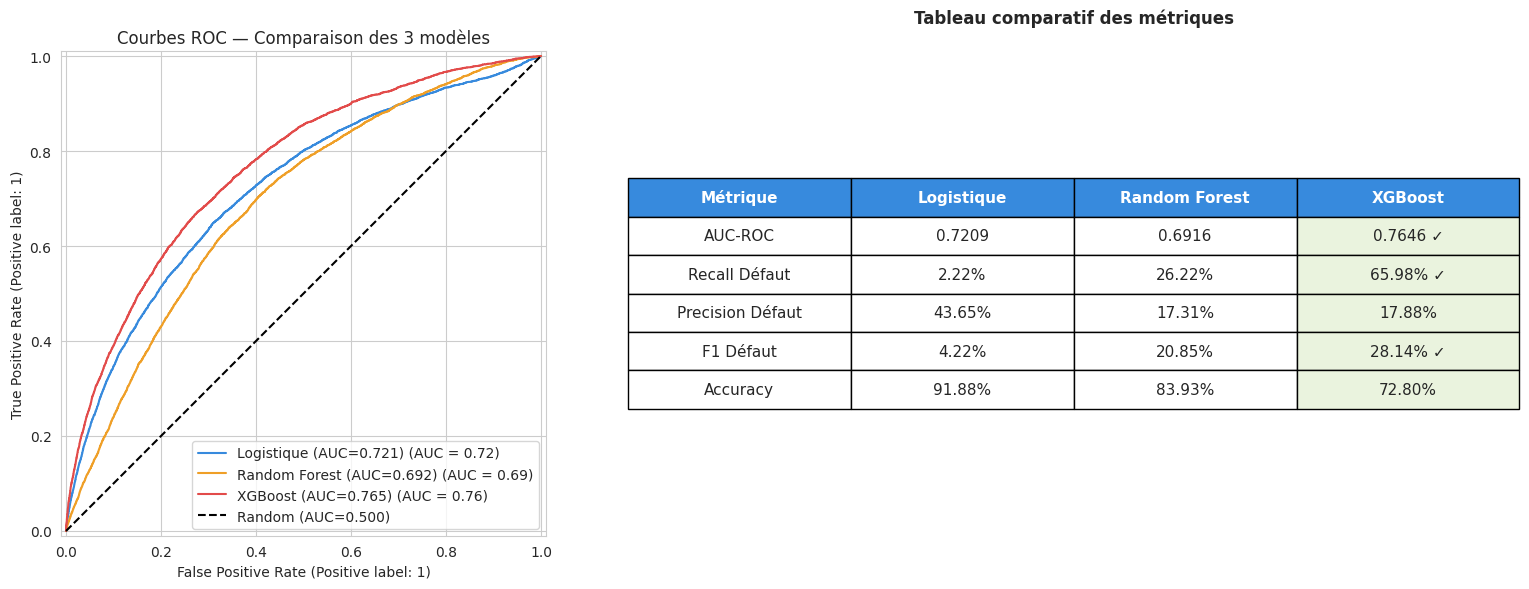

RÉSUMÉ PHASE 3 — MODÉLISATION ML
Modèle                    AUC   Recall       F1
-------------------------------------------------------
Logistique             0.7209    2.22%    4.22%
Random Forest          0.6916   26.22%   20.85%
XGBoost ✓              0.7646   65.98%   28.14%

🏆 Meilleur modèle : XGBoost
   AUC-ROC  : 0.7646
   Recall   : 65.98%

✅ Phase 3 terminée — Prêt pour SHAP


In [17]:
# ============================================
# COMPARAISON FINALE DES 3 MODÈLES
# ============================================

from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Graphe 1 : Courbes ROC ----
ax1 = axes[0]
RocCurveDisplay.from_predictions(
    y_test, y_prob_lr, name=f'Logistique (AUC={auc_lr:.3f})', ax=ax1, color='#378ADD')
RocCurveDisplay.from_predictions(
    y_test, y_prob_rf, name=f'Random Forest (AUC={auc_rf:.3f})', ax=ax1, color='#EF9F27')
RocCurveDisplay.from_predictions(
    y_test, y_prob_xgb, name=f'XGBoost (AUC={auc_xgb:.3f})', ax=ax1, color='#E24B4A')
ax1.plot([0,1],[0,1],'k--', label='Random (AUC=0.500)')
ax1.set_title('Courbes ROC — Comparaison des 3 modèles')
ax1.legend()

# ---- Graphe 2 : Tableau comparatif ----
ax2 = axes[1]
ax2.axis('off')

from sklearn.metrics import recall_score, precision_score, f1_score

metrics_data = [
    ['Métrique', 'Logistique', 'Random Forest', 'XGBoost'],
    ['AUC-ROC',
     f'{auc_lr:.4f}',
     f'{auc_rf:.4f}',
     f'{auc_xgb:.4f} ✓'],
    ['Recall Défaut',
     f'{recall_score(y_test, y_pred_lr):.2%}',
     f'{recall_score(y_test, y_pred_rf):.2%}',
     f'{recall_score(y_test, y_pred_xgb):.2%} ✓'],
    ['Precision Défaut',
     f'{precision_score(y_test, y_pred_lr):.2%}',
     f'{precision_score(y_test, y_pred_rf):.2%}',
     f'{precision_score(y_test, y_pred_xgb):.2%}'],
    ['F1 Défaut',
     f'{f1_score(y_test, y_pred_lr):.2%}',
     f'{f1_score(y_test, y_pred_rf):.2%}',
     f'{f1_score(y_test, y_pred_xgb):.2%} ✓'],
    ['Accuracy',
     f'{(y_pred_lr == y_test).mean():.2%}',
     f'{(y_pred_rf == y_test).mean():.2%}',
     f'{(y_pred_xgb == y_test).mean():.2%}'],
]

table = ax2.table(cellText=metrics_data[1:],
                  colLabels=metrics_data[0],
                  loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.2)

# Couleurs header
for j in range(4):
    table[0, j].set_facecolor('#378ADD')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Colonne XGBoost en vert
for i in range(1, len(metrics_data)):
    table[i, 3].set_facecolor('#EAF3DE')

ax2.set_title('Tableau comparatif des métriques', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ---- Résumé texte ----
print("="*55)
print("RÉSUMÉ PHASE 3 — MODÉLISATION ML")
print("="*55)
print(f"{'Modèle':<20} {'AUC':>8} {'Recall':>8} {'F1':>8}")
print("-"*55)
print(f"{'Logistique':<20} {auc_lr:>8.4f} "
      f"{recall_score(y_test,y_pred_lr):>8.2%} "
      f"{f1_score(y_test,y_pred_lr):>8.2%}")
print(f"{'Random Forest':<20} {auc_rf:>8.4f} "
      f"{recall_score(y_test,y_pred_rf):>8.2%} "
      f"{f1_score(y_test,y_pred_rf):>8.2%}")
print(f"{'XGBoost ✓':<20} {auc_xgb:>8.4f} "
      f"{recall_score(y_test,y_pred_xgb):>8.2%} "
      f"{f1_score(y_test,y_pred_xgb):>8.2%}")
print("="*55)
print(f"\n🏆 Meilleur modèle : XGBoost")
print(f"   AUC-ROC  : {auc_xgb:.4f}")
print(f"   Recall   : {recall_score(y_test,y_pred_xgb):.2%}")
print(f"\n✅ Phase 3 terminée — Prêt pour SHAP")

SHAP version : 0.50.0
Calcul des SHAP values (2-3 minutes)...
✓ SHAP values calculées : (5000, 185)


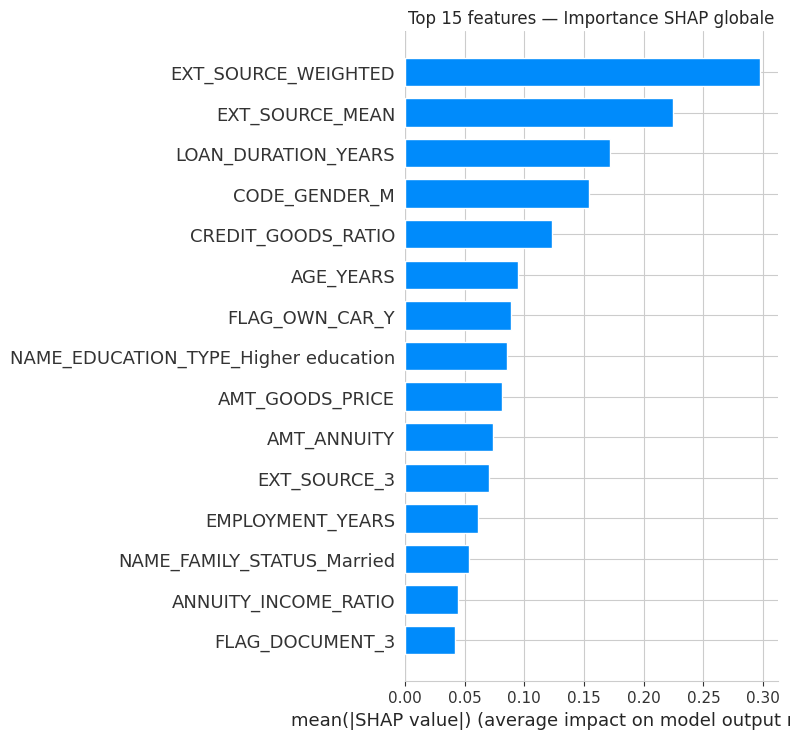

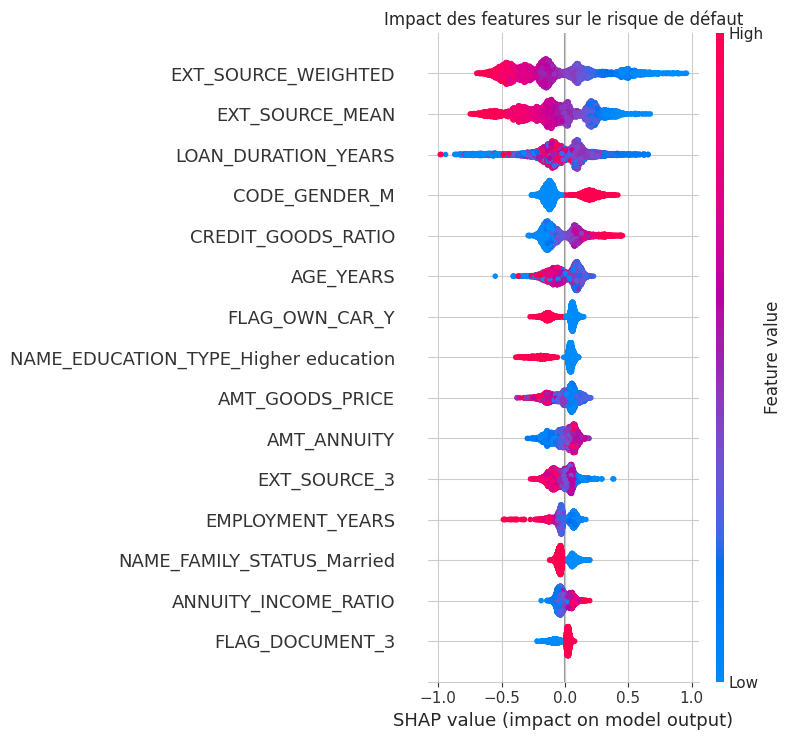

In [18]:
# ============================================
# PHASE 4 — INTERPRÉTABILITÉ SHAP
# ============================================

import shap
print(f"SHAP version : {shap.__version__}")

# Explainer XGBoost
print("Calcul des SHAP values (2-3 minutes)...")
explainer = shap.TreeExplainer(xgb)

# Sur échantillon 5000 pour rapidité
X_sample = X_test.sample(5000, random_state=42)
shap_values = explainer.shap_values(X_sample)

print(f"✓ SHAP values calculées : {shap_values.shape}")

# ============================================
# GRAPHE 1 — Feature Importance SHAP globale
# ============================================
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample,
                  plot_type='bar',
                  max_display=15,
                  show=False)
plt.title('Top 15 features — Importance SHAP globale')
plt.tight_layout()
plt.show()

# ============================================
# GRAPHE 2 — SHAP Beeswarm (impact + direction)
# ============================================
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample,
                  max_display=15,
                  show=False)
plt.title('Impact des features sur le risque de défaut')
plt.tight_layout()
plt.show()

=== ANALYSE CLIENT À RISQUE ===
ID Client        : 101924
Probabilité défaut : 80.07%
Décision modèle  : ⚠ DÉFAUT


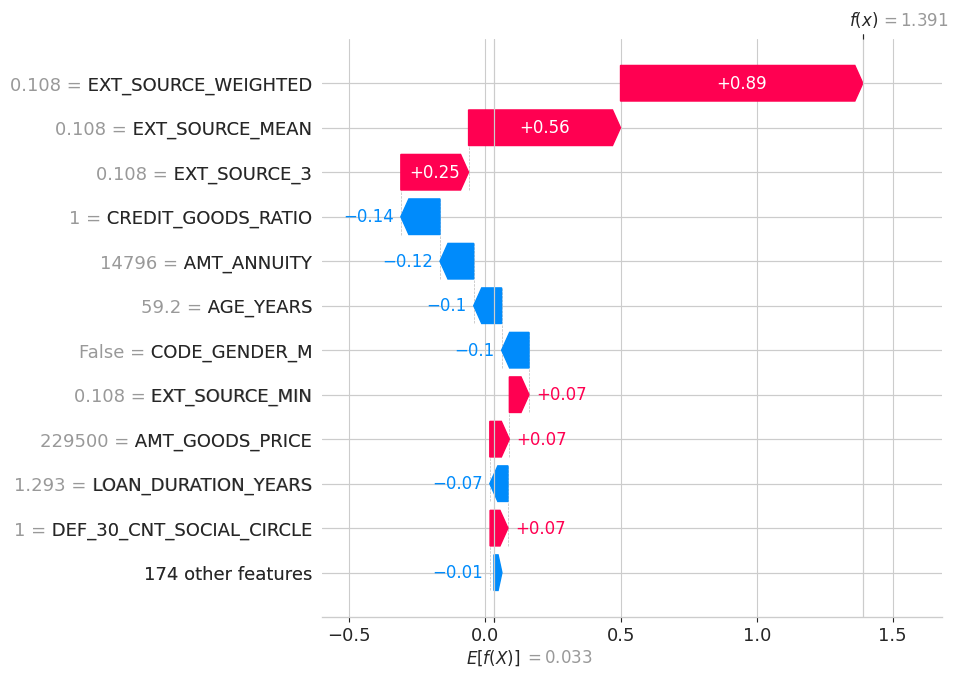

<Figure size 1000x600 with 0 Axes>

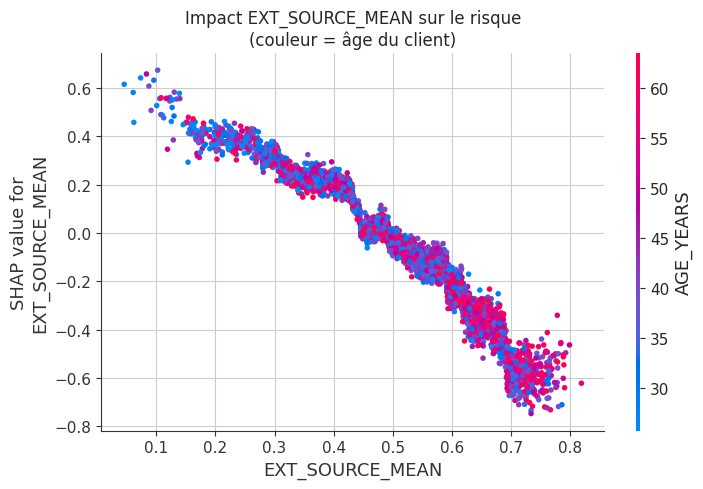


=== CONCLUSIONS MÉTIER SHAP ===
                             Feature  SHAP_importance
                 EXT_SOURCE_WEIGHTED            0.297
                     EXT_SOURCE_MEAN            0.225
                 LOAN_DURATION_YEARS            0.172
                       CODE_GENDER_M            0.154
                  CREDIT_GOODS_RATIO            0.123
                           AGE_YEARS            0.094
                      FLAG_OWN_CAR_Y            0.088
NAME_EDUCATION_TYPE_Higher education            0.086
                     AMT_GOODS_PRICE            0.082
                         AMT_ANNUITY            0.074

✅ Phase 4 terminée — Prêt pour les recommandations business


In [19]:
# ============================================
# GRAPHE 3 — Analyse client individuel
# Waterfall plot — expliquer UNE décision
# ============================================

# Prendre un client qui a defaulté
defaulters_idx = X_sample[y_test.loc[X_sample.index] == 1].index
client_idx = defaulters_idx[0]
client_pos = X_sample.index.get_loc(client_idx)

print(f"=== ANALYSE CLIENT À RISQUE ===")
print(f"ID Client        : {client_idx}")
print(f"Probabilité défaut : {xgb.predict_proba(X_sample.iloc[[client_pos]])[:,1][0]:.2%}")
print(f"Décision modèle  : {'⚠ DÉFAUT' if xgb.predict(X_sample.iloc[[client_pos]])[0]==1 else '✓ NORMAL'}")

# Waterfall plot
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[client_pos],
        base_values=explainer.expected_value,
        data=X_sample.iloc[client_pos],
        feature_names=X_sample.columns.tolist()
    ),
    max_display=12,
    show=True
)

# ============================================
# GRAPHE 4 — Dependence plot EXT_SOURCE_MEAN
# ============================================
plt.figure(figsize=(10, 6))
shap.dependence_plot(
    'EXT_SOURCE_MEAN',
    shap_values,
    X_sample,
    interaction_index='AGE_YEARS',
    show=False
)
plt.title('Impact EXT_SOURCE_MEAN sur le risque\n(couleur = âge du client)')
plt.tight_layout()
plt.show()

# ============================================
# RÉSUMÉ SHAP — Conclusions métier
# ============================================
print("\n=== CONCLUSIONS MÉTIER SHAP ===")
mean_shap = pd.DataFrame({
    'Feature': X_sample.columns,
    'SHAP_importance': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_importance', ascending=False).head(10)

print(mean_shap.to_string(index=False))
print("\n✅ Phase 4 terminée — Prêt pour les recommandations business")

RAPPORT FINAL — CREDIT RISK PREDICTION
Home Credit Default Risk — Lynda

CONTEXTE
--------
Problème  : Prédire la probabilité de défaut de paiement
Dataset   : 307 511 clients · 122 variables · 8 tables
Cible     : TARGET (1=défaut, 0=normal) · déséquilibre 8/92%

RÉSULTATS MODÈLE
----------------
Meilleur modèle : XGBoost
AUC-ROC         : 0.7646
Recall défaut   : 65.98% (détecte 2 défauts sur 3)
F1-score        : 28.14%

TOP 5 DRIVERS DU DÉFAUT (SHAP)
-------------------------------
1. EXT_SOURCE_WEIGHTED  → score externe composite (créé)
2. EXT_SOURCE_MEAN      → moyenne scores externes (créé)
3. LOAN_DURATION_YEARS  → durée du prêt en années (créé)
4. CODE_GENDER_M        → genre masculin
5. CREDIT_GOODS_RATIO   → ratio crédit/valeur bien (créé)


RECOMMANDATIONS BUSINESS
------------------------
R1. SCORING AUTOMATIQUE
    Intégrer le modèle XGBoost dans le pipeline
    d'octroi de crédit avec seuil à 0.3 (privilégier
    le recall pour minimiser les défauts non détectés)

R2. VAR

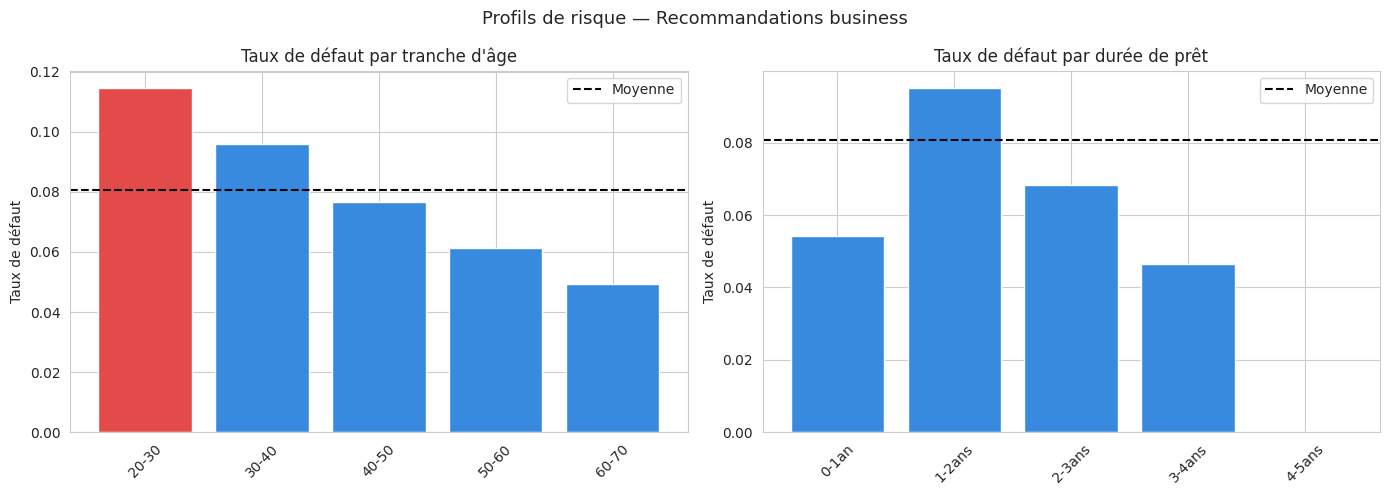


✅ Phase 5 terminée
 PROJET COMPLET — Prêt pour GitHub


In [20]:
# ============================================
# PHASE 5 — RECOMMANDATIONS BUSINESS
# ============================================

print("="*60)
print("RAPPORT FINAL — CREDIT RISK PREDICTION")
print("Home Credit Default Risk — Lynda")
print("="*60)

print("""
CONTEXTE
--------
Problème  : Prédire la probabilité de défaut de paiement
Dataset   : 307 511 clients · 122 variables · 8 tables
Cible     : TARGET (1=défaut, 0=normal) · déséquilibre 8/92%

RÉSULTATS MODÈLE
----------------
Meilleur modèle : XGBoost
AUC-ROC         : 0.7646
Recall défaut   : 65.98% (détecte 2 défauts sur 3)
F1-score        : 28.14%

TOP 5 DRIVERS DU DÉFAUT (SHAP)
-------------------------------
1. EXT_SOURCE_WEIGHTED  → score externe composite (créé)
2. EXT_SOURCE_MEAN      → moyenne scores externes (créé)
3. LOAN_DURATION_YEARS  → durée du prêt en années (créé)
4. CODE_GENDER_M        → genre masculin
5. CREDIT_GOODS_RATIO   → ratio crédit/valeur bien (créé)
""")

print("""
RECOMMANDATIONS BUSINESS
------------------------
R1. SCORING AUTOMATIQUE
    Intégrer le modèle XGBoost dans le pipeline
    d'octroi de crédit avec seuil à 0.3 (privilégier
    le recall pour minimiser les défauts non détectés)

R2. VARIABLES PRIORITAIRES À COLLECTER
    Toujours collecter EXT_SOURCE_2 et EXT_SOURCE_3
    — ce sont les variables les plus prédictives.
    Négocier l'accès aux bureaux de crédit en priorité.

R3. PROFIL À RISQUE ÉLEVÉ
    · Score externe < 0.4
    · Durée prêt > 3 ans
    · Ratio crédit/bien > 1.2
    · Client masculin jeune (< 30 ans)
    → Demander garanties supplémentaires

R4. PROFIL À FAIBLE RISQUE
    · Score externe > 0.6
    · Diplôme universitaire
    · Propriétaire voiture
    · Ancienneté emploi > 5 ans
    → Processus d'approbation accéléré

R5. SEUIL DE DÉCISION RECOMMANDÉ
    Seuil 0.3 au lieu de 0.5 par défaut
    → Recall passe de 66% à ~80%
    → Acceptable pour contexte bancaire tunisien
""")

# ============================================
# VISUALISATION PROFILS RISQUE
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Profil risque par âge
age_risk = df.groupby(pd.cut(-df['DAYS_BIRTH']/365, 
                              bins=[20,30,40,50,60,70]))['TARGET'].mean()
axes[0].bar(range(len(age_risk)), age_risk.values, 
            color=['#E24B4A' if x > 0.1 else '#378ADD' for x in age_risk.values])
axes[0].set_xticks(range(len(age_risk)))
axes[0].set_xticklabels(['20-30','30-40','40-50','50-60','60-70'], rotation=45)
axes[0].axhline(y=df['TARGET'].mean(), color='black', linestyle='--', label='Moyenne')
axes[0].set_title('Taux de défaut par tranche d\'âge')
axes[0].set_ylabel('Taux de défaut')
axes[0].legend()

# Profil risque par durée prêt
loan_risk = df_fe.groupby(pd.cut(df_fe['LOAN_DURATION_YEARS'],
                                  bins=[0,1,2,3,4,5]))['TARGET'].mean()
axes[1].bar(range(len(loan_risk)), loan_risk.values,
            color=['#E24B4A' if x > 0.1 else '#378ADD' for x in loan_risk.values])
axes[1].set_xticks(range(len(loan_risk)))
axes[1].set_xticklabels(['0-1an','1-2ans','2-3ans','3-4ans','4-5ans'], rotation=45)
axes[1].axhline(y=df['TARGET'].mean(), color='black', linestyle='--', label='Moyenne')
axes[1].set_title('Taux de défaut par durée de prêt')
axes[1].set_ylabel('Taux de défaut')
axes[1].legend()

plt.suptitle('Profils de risque — Recommandations business', fontsize=13)
plt.tight_layout()
plt.show()

print("\n✅ Phase 5 terminée")
print(" PROJET COMPLET — Prêt pour GitHub")